In [68]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import plotly.express as px

In [36]:
df = pd.read_csv('student_clustering.csv')
df

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110
...,...,...
195,4.68,89
196,8.57,118
197,5.85,112
198,6.23,108


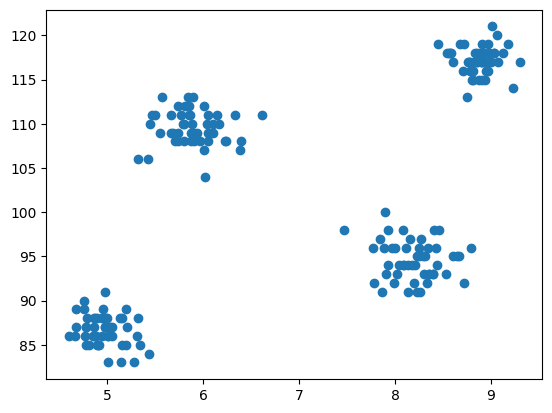

In [37]:
plt.scatter(df['cgpa'], df['iq'])
plt.show()

[29957.898288, 4184.14127, 2364.005583420083, 681.96966, 599.4812142280703, 424.57080334260974, 295.43918959431915, 249.63018358945303, 215.76055329305515, 207.7509101250968]


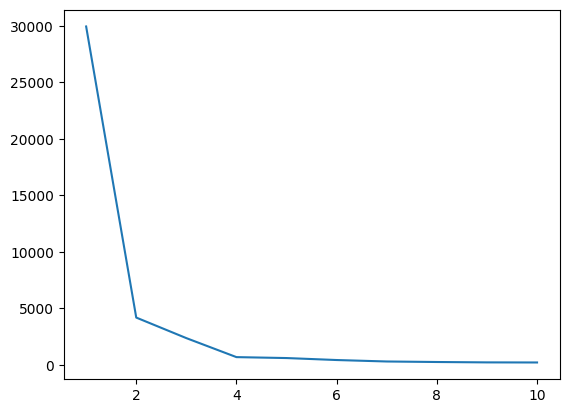

In [75]:
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i)
    km.fit_predict(df)
    wcss.append(km.inertia_)
    
print(wcss)
plt.plot(range(1,11), wcss)
plt.show()

In [76]:
X = df.iloc[:,:].values
km = KMeans(n_clusters=4)
y_means = km.fit_predict(X)

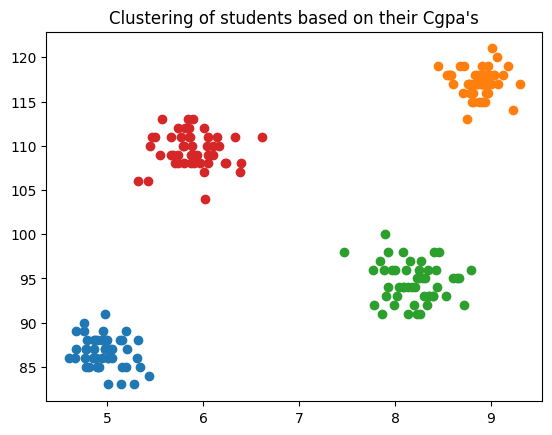

In [77]:
plt.title("Clustering of students based on their Cgpa's")
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1])
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1])
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1])
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1])
plt.show()

### K-means on 3D Data

In [78]:
centroids = [(-5, -5, 5), (5, 5, -5), (3.5, -2.5, 4), (-2.5, 2.5, -4)]
cluster_std = [1, 1, 1, 1]

X, y = make_blobs(n_samples=200,
                  cluster_std=cluster_std,
                  centers=centroids,
                  n_features=3,
                  random_state=1
)

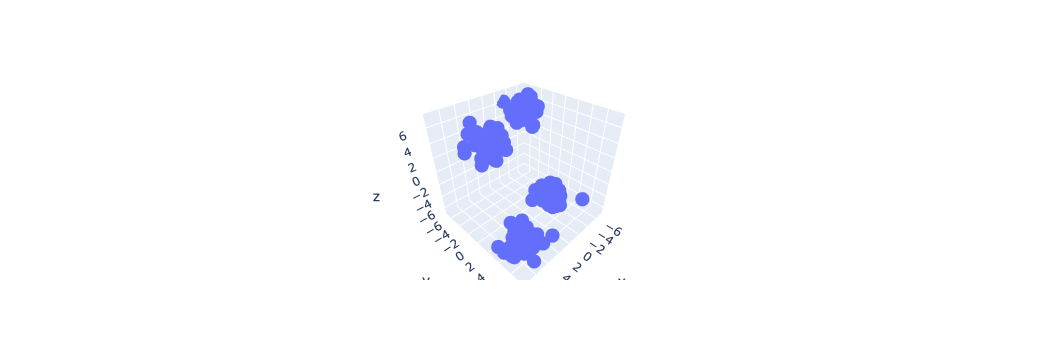

In [79]:
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()

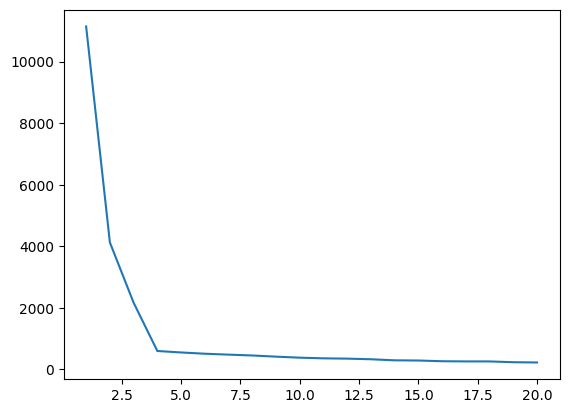

In [81]:
wcss = []

for i in range(1, 21):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 21), wcss)
plt.show()

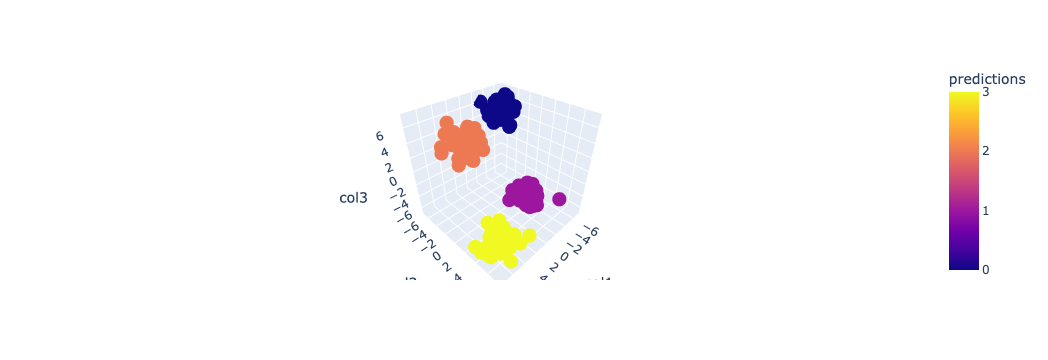

In [88]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(X)

df = pd.DataFrame()
df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['predictions'] = y_pred

fig = px.scatter_3d(df,
                    x='col1',
                    y='col2',
                    z='col3',
                    color='predictions'
)
fig.show()